In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
ticker = 'AAPL'
df = yf.download(ticker, '2020-01-01')

C:\Users\dhruv\AppData\Local\Temp\ipykernel_1736\2867026071.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, '2020-01-01')
[*********************100%***********************]  1 of 1 completed


In [4]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.468246,72.528566,71.223244,71.476585,135480400
2020-01-03,71.763725,72.523754,71.539337,71.696167,146322800
2020-01-06,72.335564,72.374169,70.634547,70.885479,118387200
2020-01-07,71.995361,72.600968,71.775796,72.345212,108872000
2020-01-08,73.153496,73.455095,71.698581,71.698581,132079200
...,...,...,...,...,...
2025-12-31,271.859985,273.679993,271.750000,273.059998,27293600
2026-01-02,271.010010,277.839996,269.000000,272.260010,37838100


In [5]:
scaler = StandardScaler()
df['Close'] = scaler.fit_transform(df['Close'])

In [6]:
train_len = 31
data = []

for i in range(len(df) - train_len):
    data.append(df['Close'][i:i+train_len])

data = np.array(data)

training = int(0.75 * len(data))

x_train = torch.from_numpy(data[:training, :-1, :]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[:training, -1, :]).type(torch.Tensor).to(device)
x_test = torch.from_numpy(data[training:, :-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[training:, -1, :]).type(torch.Tensor).to(device)

In [7]:
data

array([[[-1.85836132],
        [-1.87247899],
        [-1.8610201 ],
        ...,
        [-1.72478885],
        [-1.73608109],
        [-1.73569338]],

       [[-1.87247899],
        [-1.8610201 ],
        [-1.86783731],
        ...,
        [-1.73608109],
        [-1.73569338],
        [-1.7645294 ]],

       [[-1.8610201 ],
        [-1.86783731],
        [-1.84462983],
        ...,
        [-1.73569338],
        [-1.7645294 ],
        [-1.74213923]],

       ...,

       [[ 2.04861438],
        [ 2.0710576 ],
        [ 2.02476831],
        ...,
        [ 2.16163219],
        [ 2.13718498],
        [ 2.1201526 ]],

       [[ 2.0710576 ],
        [ 2.02476831],
        [ 2.12977077],
        ...,
        [ 2.13718498],
        [ 2.1201526 ],
        [ 2.04500757]],

       [[ 2.02476831],
        [ 2.12977077],
        [ 2.21854257],
        ...,
        [ 2.1201526 ],
        [ 2.04500757],
        [ 1.94681757]]], shape=(1481, 31, 1))

In [8]:
class PredictionModel(nn.Module):

    def __init__ (self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.15)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])

        return out

In [9]:
model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to(device)

In [10]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [11]:
num_epochs = 200

for i in range(num_epochs):
    y_train_pred = model(x_train)

    loss = criterion(y_train_pred, y_train)

    if i % 20 == 0:
        print(i, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

0 0.5980008244514465
20 0.022036541253328323
40 0.0081587303429842
60 0.006479755509644747
80 0.006097653415054083
100 0.005513333715498447
120 0.005266796797513962
140 0.005007283762097359
160 0.0047703939490020275
180 0.004755385220050812


In [12]:
model.eval()

y_test_pred = model(x_test)
y_train_pred = scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test = scaler.inverse_transform(y_test.detach().cpu().numpy())


In [13]:
train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])

In [14]:
train_rmse

3.3646798133850098

In [15]:
test_rmse

6.904831409454346

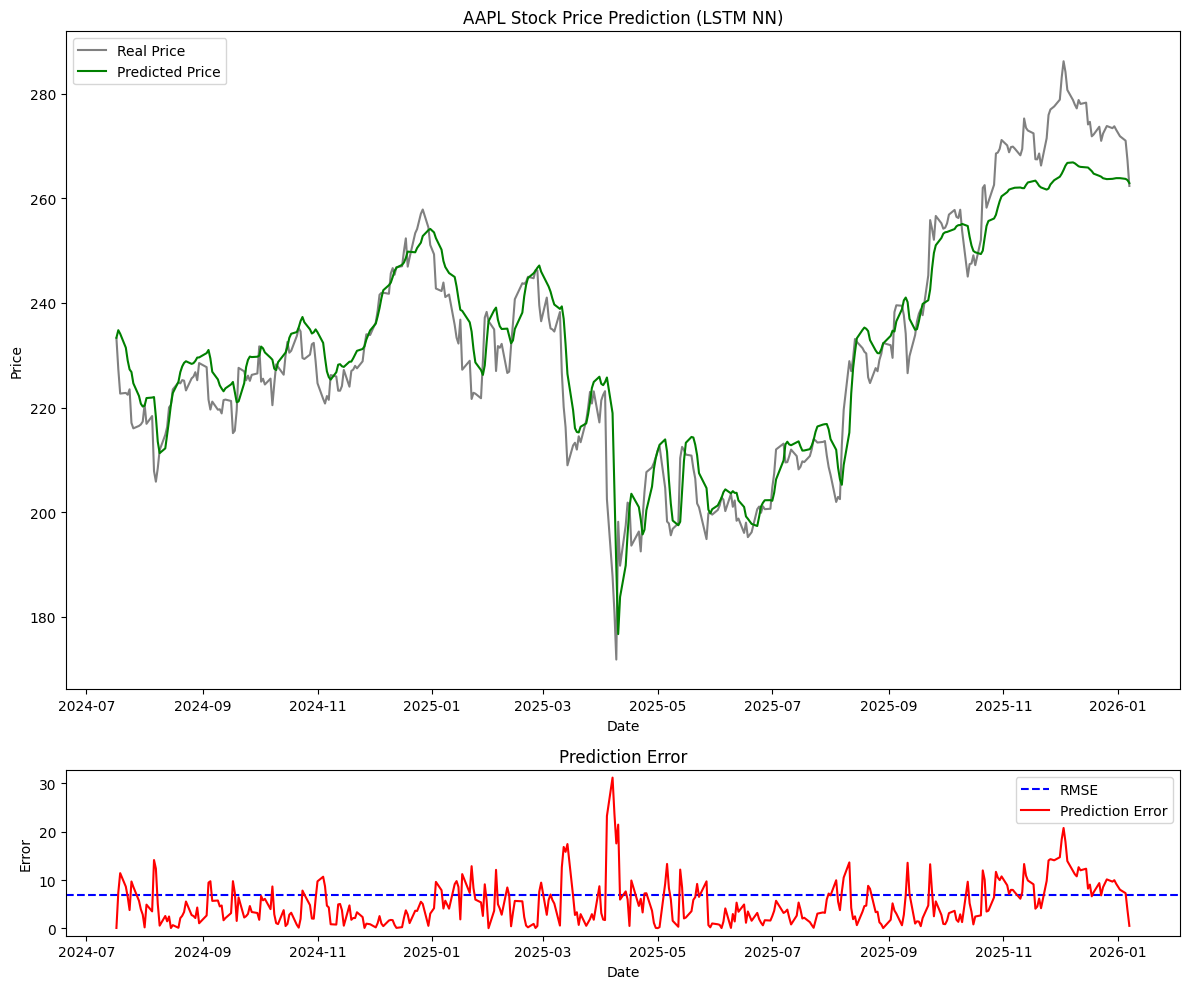

In [16]:
fig = plt.figure(figsize=(12, 10))

gs = fig.add_gridspec(4, 1)

ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color = 'gray', label = 'Real Price')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color = 'green', label = 'Predicted Price')
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction (LSTM NN)")
plt.xlabel("Date")
plt.ylabel('Price')

ax2 = fig.add_subplot(gs[3, 0])
ax2.axhline(test_rmse, color = 'blue', linestyle = '--', label = 'RMSE')
ax2.plot(df.iloc[-len(y_test):].index, abs(y_test - y_test_pred), 'r', label = 'Prediction Error')
ax2.legend()
plt.title('Prediction Error')
plt.xlabel('Date')
plt.ylabel('Error')
plt.tight_layout()
plt.show()